**House Price Prediction**

**Dataset:** California Housing Prices - `housing.csv`

**Kaggle link:** https://www.kaggle.com/datasets/camnugent/california-housing-prices

> Process: EDA → preprocessing → baseline model → model selection (CV) → tuning (GridSearchCV) → final evaluation → inference.


**1. Setup**

In [1]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn
# external gradient boosting libraries used later (optional - notebook still runs without them)
%pip install -q xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# --- regression models, grouped by family ---
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    BayesianRidge, HuberRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, BaggingRegressor,
    AdaBoostRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

In [7]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH = "/content/drive/MyDrive/Study/Jhankar Mahbub/Phitron ML AI/Main course/ML without git/ML practice self/Machine Learning Projects/ML End-to-End Workflow/Regression/housing.csv"          # update path for a different dataset
TARGET_COL = "median_house_value" # target column name

**2. Load Data**

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
df = pd.read_csv(CSV_PATH)

In [10]:
print("DataFrame shape:", df.shape)

DataFrame shape: (20640, 10)


In [11]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY


**3. Exploratory Data Analysis (EDA)**

In [12]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

**Column details:**

1. longitude: A measure of how far west a house is; a higher value is farther west

2. latitude: A measure of how far north a house is; a higher value is farther north

3. housingMedianAge: Median age of a house within a block; a lower number is a newer building

4. totalRooms: Total number of rooms within a block

5. totalBedrooms: Total number of bedrooms within a block

6. population: Total number of people residing within a block

7. households: Total number of households, a group of people residing within a home unit, for a block

8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. medianHouseValue: Median house value for households within a block (measured in US Dollars)

10. oceanProximity: Location of the house w.r.t ocean/sea

In [13]:
# basic dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [14]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Target column:", TARGET_COL)
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Target column: median_house_value
Numerical columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical columns: ['ocean_proximity']


In [15]:
# missing values analysis
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [16]:
# check presence of encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(20))

longitude
-118.310    162
-118.300    160
-118.290    148
-118.270    144
-118.320    142
-118.280    141
-118.350    140
-118.360    138
-118.190    135
-118.250    128
-118.370    128
-118.200    126
-118.140    125
-118.260    121
-118.130    121
-118.180    120
-118.340    119
-118.210    118
-118.150    116
-118.120    112
Name: count, dtype: int64
latitude
34.060    244
34.050    236
34.080    234
34.070    231
34.040    221
34.090    212
34.020    208
34.100    203
34.030    193
33.930    181
33.940    175
33.970    172
33.990    168
33.880    164
33.980    162
34.110    162
34.160    159
34.120    158
34.150    157
34.010    156
Name: count, dtype: int64
housing_median_age
52.000    1273
36.000     862
35.000     824
16.000     771
17.000     698
34.000     689
26.000     619
33.000     615
18.000     570
25.000     566
32.000     565
37.000     537
15.000     512
19.000     502
27.000     488
24.000     478
30.000     476
28.000     471
20.000     465
29.000     461
Name: coun

**NOTE: total_bedrooms has missing values**

In [17]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

# (optional) drop duplicates if present
# df = df.drop_duplicates()
# print("Shape after dropping duplicates:", df.shape)

Number of duplicate rows: 0


In [18]:
# descriptive stat
df[num_cols].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000,20640.000,20640.000,20640.000,20433.000,20640.000,20640.000,20640.000,20640.000
mean,-119.570,35.632,28.639,2635.763,537.871,1425.477,499.540,3.871,206855.817
std,2.004,2.136,12.586,2181.615,421.385,1132.462,382.330,1.900,115395.616
min,-124.350,32.540,1.000,2.000,1.000,3.000,1.000,0.500,14999.000
25%,-121.800,33.930,18.000,1447.750,296.000,787.000,280.000,2.563,119600.000
50%,-118.490,34.260,29.000,2127.000,435.000,1166.000,409.000,3.535,179700.000
75%,-118.010,37.710,37.000,3148.000,647.000,1725.000,605.000,4.743,264725.000
max,-114.310,41.950,52.000,39320.000,6445.000,35682.000,6082.000,15.000,500001.000


In [19]:
# descriptive stat
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.000,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
latitude,20640.000,35.632,2.136,32.540,33.930,34.260,37.710,41.950
housing_median_age,20640.000,28.639,12.586,1.000,18.000,29.000,37.000,52.000
total_rooms,20640.000,2635.763,2181.615,2.000,1447.750,2127.000,3148.000,39320.000
total_bedrooms,20433.000,537.871,421.385,1.000,296.000,435.000,647.000,6445.000
population,20640.000,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
households,20640.000,499.540,382.330,1.000,280.000,409.000,605.000,6082.000
median_income,20640.000,3.871,1.900,0.500,2.563,3.535,4.743,15.000
median_house_value,20640.000,206855.817,115395.616,14999.000,119600.000,179700.000,264725.000,500001.000


**Data Visualization**

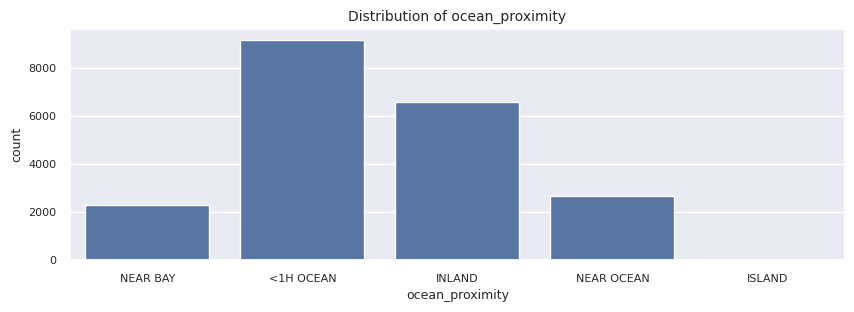

In [20]:
# countplot for categorical columns
for col in cat_cols:
    plt.figure(figsize=(10, 3))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

In [21]:
for col in cat_cols:
    print(df[col].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


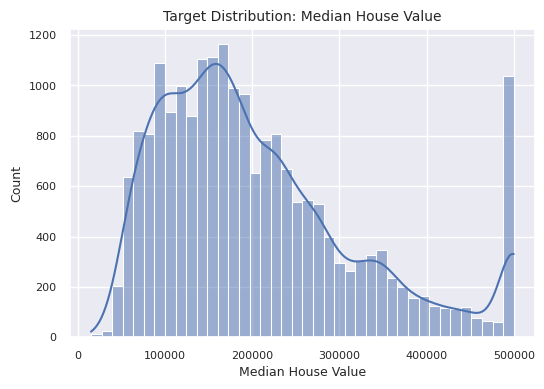

In [22]:
# target column distribution
plt.figure(figsize=(6,4))
sns.histplot(df[TARGET_COL], bins=40, kde=True)
plt.title("Target Distribution: Median House Value")
plt.xlabel("Median House Value")
plt.show()

In [23]:
df[TARGET_COL].value_counts()
# higher cap

,count
median_house_value,
500001.000,965
137500.000,122
162500.000,117
112500.000,103
187500.000,93
...,...
34200.000,1
46200.000,1
352000.000,1


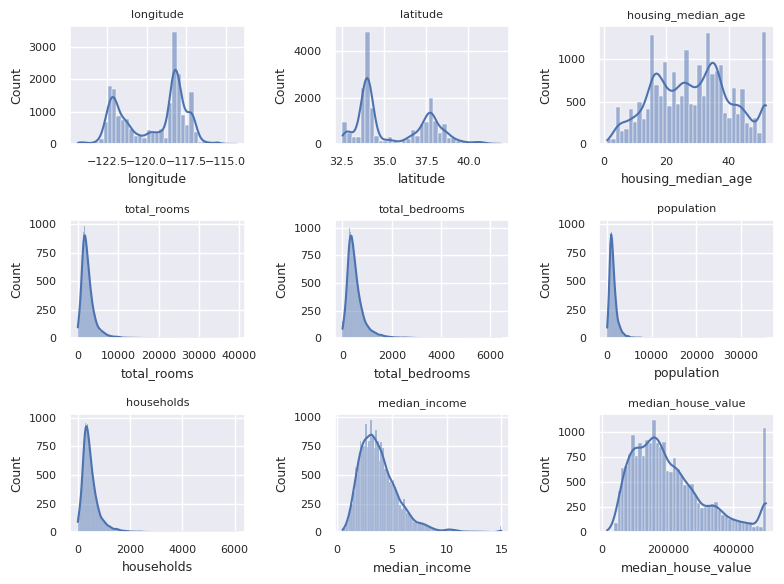

In [24]:
# histogram plot - distribution
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

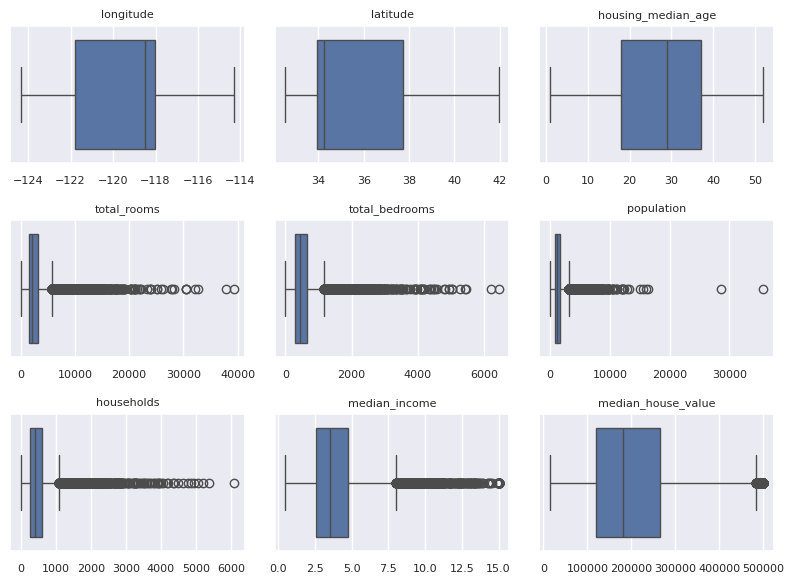

In [25]:
# outliers analysis - boxplot
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

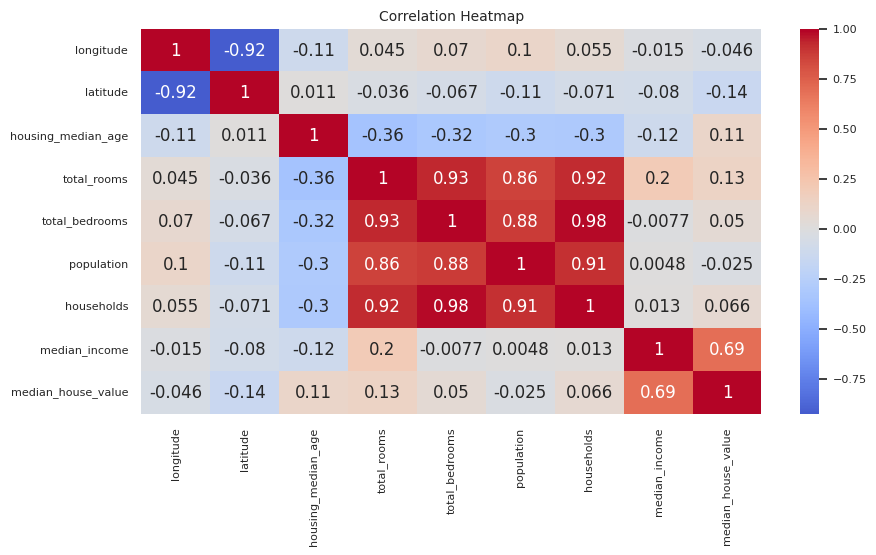

In [26]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(10, 5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

In [27]:
# Correlation with target
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("\nCorrelation with target:")
print(corr_with_target)


Correlation with target:
median_house_value    1.000
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


---

Key Insights from EDA
- Dataset has numeric + one categorical feature (ocean_proximity)
- Only total_bedrooms has missing values
- Target (median_house_value) is right-skewed and capped
- Several features show strong skew and outliers
- median_income is the strongest predictor
- High multicollinearity among room and population features

⸻

Preprocessing & Evaluation Plan
- Median imputation for missing values
- One-hot encoding for categorical feature
- Feature scaling for linear models
- Use pipelines to avoid data leakage
- Baseline model → CV model selection → hyperparameter tuning
- Primary metric: RMSE, secondary: MAE and R²
- Final evaluation only on test set


---

**4. Data Preprocessing**

In [28]:
# separate features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [29]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,NEAR BAY


In [30]:
y.head()

,median_house_value
0,452600.000
1,358500.000
2,352100.000
3,341300.000
4,342200.000


In [31]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [32]:
print("Train shape:", X_train.shape)

print("Test shape:", X_test.shape)

Train shape: (16512, 9)
Test shape: (4128, 9)


**Preprocessing Pipeline**

In [33]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

# numerical features - preprocessing steps
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# categorical features - preprocessing steps
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numerical features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical features: ['ocean_proximity']


**5. Baseline model (No CV, No Tuning)**

In [34]:
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

In [35]:
# preprocess the data and train the baseline model
baseline_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model', LinearRegression())])

**Evaluation of baseline model**

In [36]:
train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)

In [37]:
train_baseline_pred[:5]

array([188628.0772436 , 290379.8948687 , 250985.48476349, 146878.07878194,
       165789.41368924])

In [38]:
y_train[:5]

,median_house_value
14196,103000.000
8267,382100.000
17445,172600.000
14265,93400.000
2271,96500.000


In [39]:
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("\n=== TRAIN BASELINE METRICS (LinearRegression) ===")
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"MAE : {train_baseline_mae:.3f}")
print(f"R2  : {train_baseline_r2:.3f}")


=== TRAIN BASELINE METRICS (LinearRegression) ===
RMSE: 68433.937
MAE : 49594.842
R2  : 0.650


In [40]:
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("\n=== TEST BASELINE METRICS (LinearRegression) ===")
print(f"RMSE: {test_baseline_rmse:.3f}")
print(f"MAE : {test_baseline_mae:.3f}")
print(f"R2  : {test_baseline_r2:.3f}")


=== TEST BASELINE METRICS (LinearRegression) ===
RMSE: 70059.193
MAE : 50670.489
R2  : 0.625


**6. Model Selection & Optimization**

### The regression models we'll compare (beginner notes)

Below are short, plain-language notes on every model. They **all share the same preprocessing pipeline**, so when we compare their scores the comparison is fair. Try to predict which family will win before you run the loop!

**🔹 Linear / regularized linear** — *draw the best straight-line relationship; fast and interpretable*
- **LinearRegression** — Fits a straight line between features and target. The simplest model and the baseline every other model should beat.
- **Ridge** — Linear regression + an **L2** penalty that shrinks large coefficients. Helps when features are correlated and reduces overfitting.
- **Lasso** — Linear regression + an **L1** penalty that can push coefficients to exactly **zero**, so it doubles as automatic feature selection.
- **ElasticNet** — A blend of Ridge (L2) and Lasso (L1). A solid default when you have many correlated features and also want some selection.
- **BayesianRidge** — Ridge done the Bayesian way: it tunes its own regularization strength automatically and can express uncertainty. Little manual tuning.
- **HuberRegressor** — A linear model that is **robust to outliers** (it down-weights extreme errors). Relevant here because the target is capped and has outliers.

**🔹 Instance-based** — *no real "training", just look at neighbors*
- **KNeighbors (KNN)** — Predicts by averaging the target of the *k* closest data points. Needs scaled features (our pipeline does this) and weakens as the number of features grows.

**🔹 Kernel method** — *fit a flexible curve within a margin*
- **SVR (Support Vector Regression)** — Fits a function inside a tolerance margin and uses kernels to capture non-linearity. Powerful, but the **slowest** model here on large data — expect it to take a while.

**🔹 Single tree** — *if/else rules; the building block of every ensemble below*
- **DecisionTree** — Splits the data into regions with yes/no questions. Very easy to interpret but **overfits badly on its own** — watch the large train-vs-test gap.

**🔹 Bagging ensembles** — *many trees in parallel, then averaged → lowers **variance***
- **RandomForest** — Many trees trained on random subsets of rows/features, then averaged. Strong, robust, and needs little tuning.
- **ExtraTrees** — Like RandomForest but split points are chosen more randomly. Often a bit faster with similar accuracy.
- **Bagging** — Generic averaging of decision trees — the core idea RandomForest is built on, shown so you see the base concept.

**🔹 Boosting ensembles** — *trees built one after another, each fixing the last one's mistakes → lowers **bias***
- **AdaBoost** — Re-weights the hard-to-predict samples each round. The original boosting idea; usually weaker than modern boosters.
- **GradientBoosting** — Each new tree fits the leftover **errors (residuals)** of the previous ones. Accurate but slower than the histogram version.
- **HistGB (HistGradientBoosting)** — A fast, modern gradient booster that bins features into histograms. Handles missing values natively and is usually a top performer.

**🔹 External boosters** *(separate libraries, added automatically if installed)*
- **XGBoost / LightGBM / CatBoost** — Highly optimized gradient boosting libraries that typically win tabular ML competitions. Loaded in the next cell only if they're installed.

> **Heads-up:** with SVR, GradientBoosting and the external boosters included, the cross-validation loop can take a few minutes. That's normal — each model is trained 5 times (once per fold).
>
> After the comparison, **Section 7** then takes one strong model (**HistGB**) and tunes it as a worked example of hyperparameter search — the same steps apply to whichever model wins for you.

In [41]:
# Optional high-performance gradient boosting libraries (separate from scikit-learn).
# If a library is not installed we simply skip it, so this notebook always runs.
external_models = {}

try:
    from xgboost import XGBRegressor
    external_models["XGBoost"] = XGBRegressor(
        random_state=RANDOM_STATE, n_estimators=400, learning_rate=0.05, n_jobs=-1
    )
except ImportError:
    print("xgboost not installed - skipping (run the pip cell at the top to add it)")

try:
    from lightgbm import LGBMRegressor
    external_models["LightGBM"] = LGBMRegressor(
        random_state=RANDOM_STATE, n_estimators=400, learning_rate=0.05, n_jobs=-1, verbose=-1
    )
except ImportError:
    print("lightgbm not installed - skipping")

try:
    from catboost import CatBoostRegressor
    external_models["CatBoost"] = CatBoostRegressor(
        random_state=RANDOM_STATE, n_estimators=400, learning_rate=0.05, verbose=0
    )
except ImportError:
    print("catboost not installed - skipping")

print("External boosters available:", list(external_models.keys()))

External boosters available: ['XGBoost', 'LightGBM', 'CatBoost']


In [42]:
# Every model below is dropped into the SAME preprocessing pipeline and scored by the
# cross-validation loop further down, so the comparison between them is completely fair.
# Models are grouped by family - see the markdown notes above for what each one does.
models = {
    # --- Linear / regularized linear (fast, interpretable baselines) ---
    "LinearRegression": LinearRegression(),
    "Ridge":            Ridge(random_state=RANDOM_STATE),
    "Lasso":            Lasso(random_state=RANDOM_STATE, max_iter=10000),
    "ElasticNet":       ElasticNet(random_state=RANDOM_STATE, max_iter=10000),
    "BayesianRidge":    BayesianRidge(),
    "HuberRegressor":   HuberRegressor(max_iter=2000),

    # --- Instance-based ---
    "KNeighbors":       KNeighborsRegressor(),

    # --- Kernel method (SLOWEST model here on 16k rows - be patient) ---
    "SVR":              SVR(),

    # --- Single decision tree (will overfit badly - that is the lesson) ---
    "DecisionTree":     DecisionTreeRegressor(random_state=RANDOM_STATE),

    # --- Bagging ensembles (many trees in parallel, averaged -> lower variance) ---
    "RandomForest":     RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "ExtraTrees":       ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "Bagging":          BaggingRegressor(random_state=RANDOM_STATE, n_jobs=-1),

    # --- Boosting ensembles (trees in sequence, each fixes prior errors -> lower bias) ---
    "AdaBoost":         AdaBoostRegressor(random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "HistGB":           HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}

# add XGBoost / LightGBM / CatBoost if they were installed (see the cell just above)
models.update(external_models)

print(f"Comparing {len(models)} regression models:")
for name in models:
    print("  -", name)

Comparing 18 regression models:
  - LinearRegression
  - Ridge
  - Lasso
  - ElasticNet
  - BayesianRidge
  - HuberRegressor
  - KNeighbors
  - SVR
  - DecisionTree
  - RandomForest
  - ExtraTrees
  - Bagging
  - AdaBoost
  - GradientBoosting
  - HistGB
  - XGBoost
  - LightGBM
  - CatBoost


In [43]:
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [44]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

In [46]:
rows = []

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({
        "model": name,
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_mae": -scores["test_mae"].mean(),
        "cv_r2": scores["test_r2"].mean()
    })


# sort based on lowest rmse value
cv_results = pd.DataFrame(rows).sort_values("cv_rmse")
print("=== CV Model Comparison ===")
print(cv_results)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


=== CV Model Comparison ===
               model    cv_rmse    cv_mae  cv_r2
16          LightGBM  46730.518 30913.455  0.837
15           XGBoost  47307.622 31194.398  0.833
14            HistGB  48277.371 32353.191  0.826
17          CatBoost  48909.278 33102.493  0.821
9       RandomForest  49445.286 32328.533  0.817
11           Bagging  51930.812 34192.852  0.798
10        ExtraTrees  52114.585 34791.660  0.797
13  GradientBoosting  55127.963 38406.835  0.773
6         KNeighbors  61625.394 41431.828  0.716
1              Ridge  68595.617 49664.331  0.648
4      BayesianRidge  68596.932 49664.631  0.648
2              Lasso  68603.233 49667.263  0.648
0   LinearRegression  68604.163 49667.159  0.648
5     HuberRegressor  69350.113 48464.894  0.640
8       DecisionTree  70085.788 44430.282  0.632
3         ElasticNet  78284.107 59429.520  0.541
12          AdaBoost  89920.823 77279.992  0.395
7                SVR 118493.630 88303.888 -0.051


In [47]:
cv_results

,model,cv_rmse,cv_mae,cv_r2
16,LightGBM,46730.518,30913.455,0.837
15,XGBoost,47307.622,31194.398,0.833
14,HistGB,48277.371,32353.191,0.826
17,CatBoost,48909.278,33102.493,0.821
9,RandomForest,49445.286,32328.533,0.817
11,Bagging,51930.812,34192.852,0.798
10,ExtraTrees,52114.585,34791.660,0.797
13,GradientBoosting,55127.963,38406.835,0.773
6,KNeighbors,61625.394,41431.828,0.716
1,Ridge,68595.617,49664.331,0.648


In [48]:
best_row = cv_results.sort_values("cv_rmse").iloc[0]

best_model_name = best_row["model"]
best_rmse = best_row["cv_rmse"]

print("Best model based on CV RMSE:")
print("Model :", best_model_name)
print("CV RMSE:", best_rmse)

Best model based on CV RMSE:
Model : LightGBM
CV RMSE: 46730.517648673784


**The winning model (lowest CV RMSE) is selected automatically above — Section 7 tunes whichever model that is.**

**7. Hyperparameter Tuning (of the winning model)**

I don't hard-code which model to tune. Instead look up `best_model_name` (the lowest-RMSE model from the comparison above), grab a sensible hyperparameter grid for it, and run `GridSearchCV`. Change nothing — if a different model wins on another machine, the right grid is used automatically.

> Each model has its own grid below. Linear models tune `alpha`, tree models tune depth/leaves, boosters tune learning rate and number of trees, etc.

In [49]:
# A small, sensible hyperparameter grid for each model (keys must match the `models` dict).
# Params are prefixed with "model__" because the estimator lives in the Pipeline step named "model".
# Only the winning model's grid is actually used. {} means "nothing to tune - just CV the defaults".
param_grids = {
    "LinearRegression": {},
    "Ridge":            {"model__alpha": [0.1, 1.0, 10.0, 100.0]},
    "Lasso":            {"model__alpha": [0.1, 1.0, 10.0, 100.0]},
    "ElasticNet":       {"model__alpha": [0.1, 1.0, 10.0], "model__l1_ratio": [0.2, 0.5, 0.8]},
    "BayesianRidge":    {},
    "HuberRegressor":   {"model__alpha": [1e-4, 1e-3, 1e-2], "model__epsilon": [1.2, 1.35, 1.5]},
    "KNeighbors":       {"model__n_neighbors": [5, 10, 20], "model__weights": ["uniform", "distance"]},
    "SVR":              {"model__C": [1.0, 10.0, 100.0], "model__gamma": ["scale", "auto"]},
    "DecisionTree":     {"model__max_depth": [None, 5, 10, 20], "model__min_samples_leaf": [1, 10, 50]},
    "RandomForest":     {"model__n_estimators": [200, 400], "model__max_depth": [None, 20], "model__min_samples_leaf": [1, 5]},
    "ExtraTrees":       {"model__n_estimators": [200, 400], "model__max_depth": [None, 20], "model__min_samples_leaf": [1, 5]},
    "Bagging":          {"model__n_estimators": [10, 50, 100]},
    "AdaBoost":         {"model__n_estimators": [100, 300], "model__learning_rate": [0.05, 0.1, 0.5]},
    "GradientBoosting": {"model__n_estimators": [200, 400], "model__learning_rate": [0.03, 0.1], "model__max_depth": [2, 3]},
    "HistGB": {
        "model__learning_rate":     [0.03, 0.05, 0.1],
        "model__max_leaf_nodes":    [15, 31, 63],
        "model__min_samples_leaf":  [20, 50, 100],
        "model__l2_regularization": [0.0, 0.1, 1.0],
    },
    "XGBoost":          {"model__n_estimators": [300, 600], "model__learning_rate": [0.03, 0.1], "model__max_depth": [4, 6]},
    "LightGBM":         {"model__n_estimators": [300, 600], "model__learning_rate": [0.03, 0.1], "model__num_leaves": [31, 63]},
    "CatBoost":         {"model__depth": [4, 6], "model__learning_rate": [0.03, 0.1]},
}

In [50]:
# `best_model_name` was set just above = the lowest-RMSE model from the CV comparison.
winning_estimator = models[best_model_name]        # fresh, unfitted estimator
param_grid = param_grids.get(best_model_name, {})  # its grid ({} -> just CV the defaults)

# rebuild the pipeline around the winning model
tune_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", winning_estimator)
    ]
)

print("Auto-tuning the winning model:", best_model_name)
print("Hyperparameter grid:", param_grid if param_grid else "{} (no tunable params)")

Auto-tuning the winning model: LightGBM
Hyperparameter grid: {'model__n_estimators': [300, 600], 'model__learning_rate': [0.03, 0.1], 'model__num_leaves': [31, 63]}


In [51]:
grid = GridSearchCV(
    estimator=tune_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

In [52]:
# perform grid search
grid.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['longitude',
                                                                          'latitude',
                                                                          'housing_median_age',
                                                                          'total_rooms',
                                                                          'total_bedrooms',
                                                                          'population',
                                                                          'households',
                                                                          'median_income'...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['ocean_proximity'])])),
                                       ('model',
                                        LGBMRegressor(learning_rate=0.05,
                                                      n_estimators=400,
                                                      n_jobs=-1,
                                                      random_state=42,
                                                      verbose=-1))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.03, 0.1],
                         'model__n_estimators': [300, 600],
                         'model__num_leaves': [31, 63]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [53]:
print(f"\n=== TUNED {best_model_name} (CV) ===")
print("Best CV RMSE:", -grid.best_score_)
print("Best params :", grid.best_params_)


=== TUNED LightGBM (CV) ===
Best CV RMSE: 46230.51961762282
Best params : {'model__learning_rate': 0.03, 'model__n_estimators': 600, 'model__num_leaves': 63}


**8. Final model (best params, already retrained)**

`GridSearchCV(refit=True)` (the default) automatically retrains the winning model with its best hyperparameters on the **full** training set. So `grid.best_estimator_` is the finished, ready-to-use pipeline — we just give it a clear name, `final_model`.

In [55]:
# GridSearchCV already refit the best pipeline on all of X_train - use it directly.
final_model = grid.best_estimator_
final_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model',
                 LGBMRegressor(learning_rate=0.03, n_estimators=600, n_jobs=-1,
                               num_leaves=63, random_state=42, verbose=-1))])

In [56]:
# (Optional) make the retraining explicit - it is already fitted, so this just re-confirms it.
final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model',
                 LGBMRegressor(learning_rate=0.03, n_estimators=600, n_jobs=-1,
                               num_leaves=63, random_state=42, verbose=-1))])

**9. Final Evaluation**

In [57]:
train_final_pred = final_model.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print(f"\n=== FINAL MODEL ({best_model_name}) Train Performance ===")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"MAE : {train_final_mae:.3f}")
print(f"R2  : {train_final_r2:.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



=== FINAL MODEL (LightGBM) Train Performance ===
RMSE: 29874.417
MAE : 20521.811
R2  : 0.933


In [58]:
test_final_pred = final_model.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print(f"\n=== FINAL MODEL ({best_model_name}) Test Performance ===")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"MAE : {test_final_mae:.3f}")
print(f"R2  : {test_final_r2:.3f}")


=== FINAL MODEL (LightGBM) Test Performance ===
RMSE: 45366.600
MAE : 29702.393
R2  : 0.843


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


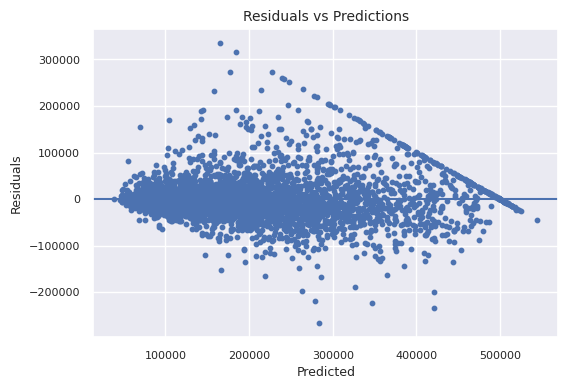

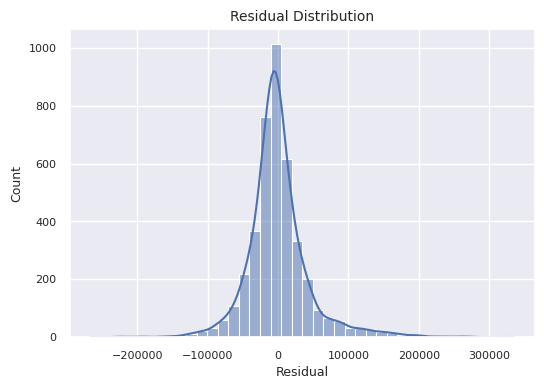

In [59]:
# residual plot
residuals = y_test - test_final_pred

plt.figure(figsize=(6, 4))
plt.scatter(test_final_pred, residuals, s=10)
plt.axhline(0)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

**10. Building a predictive system**

In [60]:
def predict_house_price(
    model,
    longitude: float,
    latitude: float,
    housing_median_age: float,
    total_rooms: float,
    total_bedrooms: float,
    population: float,
    households: float,
    median_income: float,
    ocean_proximity: str
) -> float:
    """
    Predict median_house_value for one new house.
    total_bedrooms can be np.nan (pipeline will impute).
    """
    new_row = pd.DataFrame([{
        "longitude": longitude,
        "latitude": latitude,
        "housing_median_age": housing_median_age,
        "total_rooms": total_rooms,
        "total_bedrooms": total_bedrooms,
        "population": population,
        "households": households,
        "median_income": median_income,
        "ocean_proximity": ocean_proximity
    }])

    return float(model.predict(new_row)[0])

In [61]:
# Example inference
example_pred = predict_house_price(
    model=final_model,
    longitude=-122.230,
    latitude=37.880,
    housing_median_age=41,
    total_rooms=880,
    total_bedrooms=129,
    population=322,
    households=126,
    median_income=8.3252,
    ocean_proximity="NEAR BAY"
 )

print("\nExample prediction:", round(example_pred, 2))


Example prediction: 454572.02


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


**11. Save & Load the Trained Model**

Persist the full pipeline (preprocessing + tuned model) with `joblib` so it can be reused for inference without retraining, then reload it and confirm the prediction is identical.

In [62]:
# persist the trained pipeline to disk (preprocessing + model together)
import joblib

MODEL_PATH = "house_price_model.pkl"
joblib.dump(final_model, MODEL_PATH)
print("Model saved to:", MODEL_PATH)

# reload and verify it produces the same prediction as the in-memory model
loaded_model = joblib.load(MODEL_PATH)

reloaded_pred = predict_house_price(
    model=loaded_model,
    longitude=-122.230,
    latitude=37.880,
    housing_median_age=41,
    total_rooms=880,
    total_bedrooms=129,
    population=322,
    households=126,
    median_income=8.3252,
    ocean_proximity="NEAR BAY"
)

print("Reloaded model prediction:", round(reloaded_pred, 2))
print("Matches in-memory model:", np.isclose(reloaded_pred, example_pred))

Model saved to: house_price_model.pkl
Reloaded model prediction: 454572.02
Matches in-memory model: True


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


**Ways to improve performance**

- Create ratio features
    - rooms_per_household
    - bedrooms_per_room
    - population_per_household
- Try log transformation on the target variable.
- Tune max_iter and max_bins for HistGradientBoosting.
- Try advanced boosting models like XGBoost or LightGBM.
- Do error analysis by location or price ranges instead of only metrics.
- Use spatial or grouped validation for location-based data.

**12. Conclusion**

- **Goal:** Predict `median_house_value` for California housing blocks from the raw `housing.csv` features.
- **Workflow:** Raw data → EDA → leakage-free preprocessing (`Pipeline` + `ColumnTransformer`) → baseline → CV model comparison (all major regression families) → automatic tuning of the winning model → final test evaluation → inference → model persistence.

The exact results depend on which model wins on your machine, so the summary below is **generated automatically** from the values computed above — re-running the notebook keeps it accurate.

**Next steps to push performance further:**
- Engineer ratio features (`rooms_per_household`, `bedrooms_per_room`, `population_per_household`).
- Log-transform the right-skewed target.
- Use spatial (grouped) cross-validation for location data.
- Error analysis by region and price band, especially around the `500001` cap.

In [63]:
# Auto-generated results summary - reads the variables computed above, so it is never stale.
from IPython.display import Markdown, display

rmse_improvement = (test_baseline_rmse - test_final_rmse) / test_baseline_rmse * 100
r2_gap = train_final_r2 - test_final_r2
gap_note = (
    "a noticeable gap (some overfitting)" if r2_gap > 0.05
    else "a small gap (generalizes well)"
)

summary = f"""
**Best model selected by cross-validation:** `{best_model_name}`

| Stage | RMSE | MAE | R² |
|---|---|---|---|
| Baseline (LinearRegression) — test | {test_baseline_rmse:,.0f} | {test_baseline_mae:,.0f} | {test_baseline_r2:.3f} |
| Tuned {best_model_name} — train | {train_final_rmse:,.0f} | {train_final_mae:,.0f} | {train_final_r2:.3f} |
| **Tuned {best_model_name} — test** | **{test_final_rmse:,.0f}** | **{test_final_mae:,.0f}** | **{test_final_r2:.3f}** |

- The tuned model explains **~{test_final_r2 * 100:.0f}%** of the variance on unseen (test) data.
- It cuts the baseline's test RMSE by **~{rmse_improvement:.0f}%**.
- Train vs test R²: **{train_final_r2:.3f}** vs **{test_final_r2:.3f}** → {gap_note}.
"""

display(Markdown(summary))


**Best model selected by cross-validation:** `LightGBM`

| Stage | RMSE | MAE | R² |
|---|---|---|---|
| Baseline (LinearRegression) — test | 70,059 | 50,670 | 0.625 |
| Tuned LightGBM — train | 29,874 | 20,522 | 0.933 |
| **Tuned LightGBM — test** | **45,367** | **29,702** | **0.843** |

- The tuned model explains **~84%** of the variance on unseen (test) data.
- It cuts the baseline's test RMSE by **~35%**.
- Train vs test R²: **0.933** vs **0.843** → a noticeable gap (some overfitting).
